In [2]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [4]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from thinkstats import decorate

In [7]:
from empiricaldist import FreqTab


In [8]:
t = [1.0, 2.0, 2.0, 3.0, 5.0]


In [9]:
ftab = FreqTab.from_seq(t)
ftab

,freqs
1.0,1
2.0,2
3.0,1
5.0,1


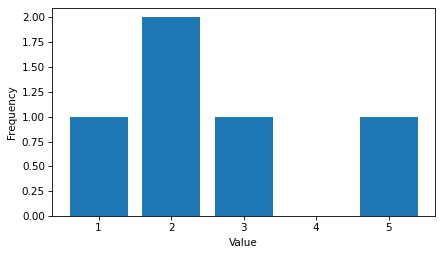

In [10]:
ftab.bar()
decorate(xlabel="Value", ylabel="Frequency")

In [11]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [12]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded nsfg.py
Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [13]:
from nsfg import read_fem_preg

preg = read_fem_preg()

c:\Users\choyo\OneDrive\Documentos\Guia Estudio - Desarrollo\think_stats_book\CHAPTER 2\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


In [14]:
live = preg.query("outcome == 1")

In [15]:
ftab_lb = FreqTab.from_seq(live["birthwgt_lb"], name="birthwgt_lb")


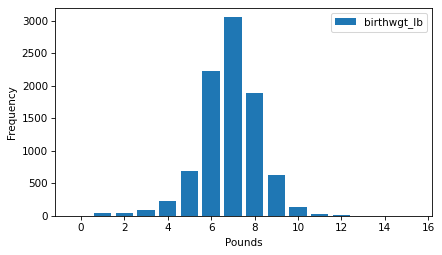

In [16]:
ftab_lb.bar()
decorate(xlabel="Pounds", ylabel="Frequency")

In [17]:
ftab_lb.idxmax()


np.float64(7.0)

In [18]:
ftab_lb.mode()


np.float64(7.0)

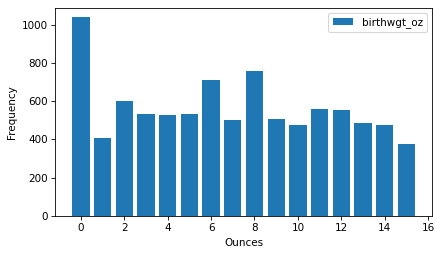

In [19]:
ftab_oz = FreqTab.from_seq(live["birthwgt_oz"], name="birthwgt_oz")
ftab_oz.bar()
decorate(xlabel="Ounces", ylabel="Frequency")

In [20]:
ftab_age = FreqTab.from_seq(live["agepreg"], name="agepreg")


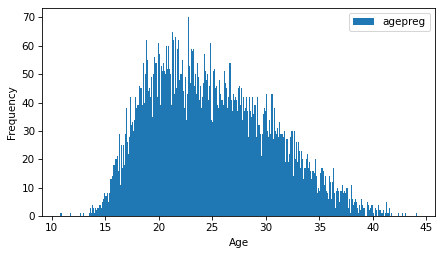

In [21]:
ftab_age.bar(width=0.1)
decorate(xlabel="Age", ylabel="Frequency")

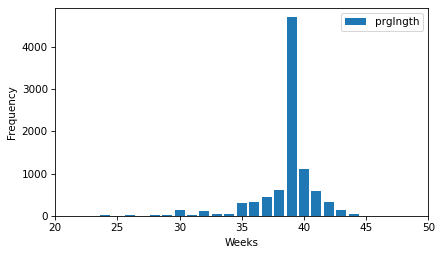

In [22]:
ftab_length = FreqTab.from_seq(live["prglngth"], name="prglngth")
ftab_length.bar()
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])

In [23]:
def smallest(ftab, n=10):
    return ftab[:n]

In [24]:
smallest(ftab_length)


prglngth
0     1
4     1
9     1
13    1
17    2
18    1
19    1
20    1
21    2
22    7
Name: prglngth, dtype: int64

In [25]:
def largest(ftab, n=10):
    return ftab[-n:]

In [26]:
largest(ftab_length)

prglngth
40    1116
41     587
42     328
43     148
44      46
45      10
46       1
47       1
48       7
50       2
Name: prglngth, dtype: int64

In [27]:
firsts = live.query("birthord == 1")
others = live.query("birthord != 1")

In [28]:
ftab_first = FreqTab.from_seq(firsts["prglngth"], name="firsts")
ftab_other = FreqTab.from_seq(others["prglngth"], name="others")

In [29]:
def two_bar_plots(ftab1, ftab2, width=0.45):
    ftab1.bar(align="edge", width=-width)
    ftab2.bar(align="edge", width=width, alpha=0.5)

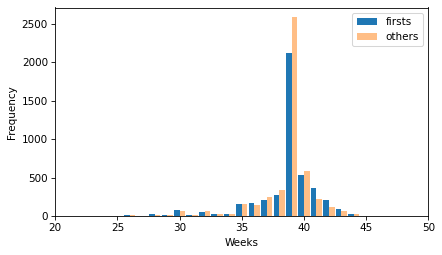

In [30]:
two_bar_plots(ftab_first, ftab_other)
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])

In [31]:
firsts["prglngth"].count(), others["prglngth"].count()

(np.int64(4413), np.int64(4735))

In [32]:
first_mean = firsts["prglngth"].mean()
other_mean = others["prglngth"].mean()
first_mean, other_mean

(np.float64(38.60095173351461), np.float64(38.52291446673706))

In [33]:
diff = first_mean - other_mean
diff, diff * 7 * 24

(np.float64(0.07803726677754952), np.float64(13.11026081862832))

In [34]:
group1, group2 = firsts["prglngth"], others["prglngth"]

In [35]:
v1, v2 = group1.var(), group2.var()

In [36]:
def cohen_effect_size(group1, group2):
    diff = group1.mean() - group2.mean()

    v1, v2 = group1.var(), group2.var()
    n1, n2 = group1.count(), group2.count()
    pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)

    return diff / np.sqrt(pooled_var)

In [37]:
cohen_effect_size(firsts["prglngth"], others["prglngth"])

np.float64(0.028879044654449834)

## Exercises

For the exercises in this chapter, we’ll load the NSFG female respondent file, which contains one row for each female respondent. Instructions for downloading the data and the codebook are in the notebook for this chapter.

In [38]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dat.gz")

Downloaded 2002FemResp.dct
Downloaded 2002FemResp.dat.gz


In [39]:
from nsfg import read_fem_resp

resp = read_fem_resp()
resp.shape

c:\Users\choyo\OneDrive\Documentos\Guia Estudio - Desarrollo\think_stats_book\CHAPTER 2\nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
c:\Users\choyo\OneDrive\Documentos\Guia Estudio - Desarrollo\think_stats_book\CHAPTER 2\nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
c:\Users\choyo\OneDrive\Documentos\Guia Estudio - Desarrollo\think_stats_book\CHAPTER 2\nsfg.py:195: PerformanceWarning: DataFrame i

(7643, 3092)

### 2.8.1 Execirse 2.1

We’ll start with totincr, which records the total income for the respondent’s family, encoded with a value from 1 to 14. You can read the codebook for the respondent file to see what income level each value represents.

Make a FreqTab object to represent the distribution of this variable and plot it as a bar chart.

In [40]:
resp['totincr'].head()

0     9
1    10
2     5
3    13
4     6
Name: totincr, dtype: int64

In [41]:
ftab_resp = FreqTab.from_seq(resp['totincr'])
ftab_resp

,freqs
totincr,
1,299
2,301
3,266
4,421
5,445
6,559
7,583
8,606
9,607


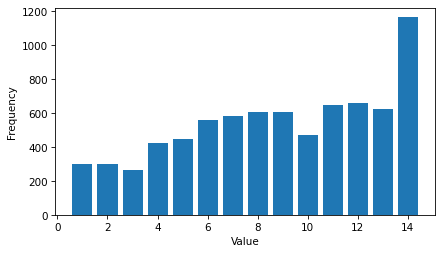

In [43]:
ftab_resp.bar()
decorate(xlabel="Value", ylabel="Frequency")

### 2.8.2 Exercise 2.2
Make a frequency table of the parity column, which records the number of children each respondent has borne. How would you describe the shape of this distribution?

Use the largest function to find the largest values of parity. Are there any values you think are errors?

In [45]:
ftab_resp_parity = FreqTab.from_seq(resp['parity'])
ftab_resp_parity

,freqs
parity,
0,3230
1,1519
2,1603
3,828
4,309
5,95
6,29
7,15
8,8


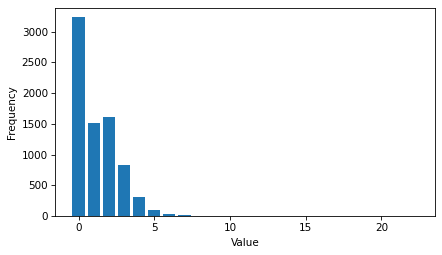

In [46]:
ftab_resp_parity.bar()
decorate(xlabel="Value", ylabel="Frequency")

es una distribuccion sesgada hacia la derecha (posiblemente por outliers). Literal, dice que hay encuestados que han tenido mas de 5 hijos. Y la mayoria de encuestados no ha tenido un hijo? Error? 

In [47]:
largest(ftab_resp_parity)

parity
3     828
4     309
5      95
6      29
7      15
8       8
9       2
10      3
16      1
22      1
Name: , dtype: int64

Pienso que el encuestado que puso 22 hijos o 16, o 10 es un outliers. 

### 2.8.3 Exercise 2.3

Let’s investigate whether women with higher or lower income bear more children. Use the query method to select the respondents with the highest income (level 14). Plot the frequency table of parity for just the high income respondents.

Compare the mean parity for high income respondents and others.

Compute Cohen’s effect size for this difference. How does it compare with the difference in pregnancy length for first babies and others?

Do these results show that people with higher income have fewer children, or can you think of another explanation for the apparent difference?

In [52]:
high_income = resp.query("totincr == 14")
low_income = resp.query("totincr == 1")
others = resp.query("totincr != 14 and totincr != 1")

print(f"Encuestados con altos ingresos {high_income.count()}")
print(f"Encuentas con bajos ingresos: {low_income.count()}")
print(f"Encuentas con ingresos no en extresos: {others.count()}")

Encuestados con altos ingresos caseid         1160
rscrinf        1160
rdormres       1160
rostscrn       1160
rscreenhisp    1160
               ... 
agemarry        769
age            1160
year           1160
decade         1160
fives          1160
Length: 3092, dtype: int64
Encuentas con bajos ingresos: caseid         299
rscrinf        299
rdormres       299
rostscrn       299
rscreenhisp    299
              ... 
agemarry        91
age            299
year           299
decade         299
fives          299
Length: 3092, dtype: int64
Encuentas con ingresos no en extresos: caseid         6184
rscrinf        6184
rdormres       6184
rostscrn       6184
rscreenhisp    6184
               ... 
agemarry       3229
age            6184
year           6184
decade         6184
fives          6184
Length: 3092, dtype: int64


Lo primero que podemos observar es que las personas con mayores ingresos llenaron mas la encuesta. 

In [64]:
import pandas as pd
ftab_resp_parity_hi = FreqTab.from_seq(high_income['parity'])
ftab_resp_parity_hi = pd.DataFrame(ftab_resp_parity_hi)
ftab_resp_parity_hi.head()


,
parity,
0,515
1,229
2,267
3,123
4,19


Una primera observacion es que las personas con altos ingresos se concentran en su mayoria en 4 o menos hijos. Igualmente, obtengamos algunos porcentajes para evaluar

In [65]:
ftab_resp_parity_hi['porc_total'] = ftab_resp_parity_hi[""] /  ftab_resp_parity_hi[""].sum() * 100
ftab_resp_parity_hi.head(20)

,,porc_total
parity,,
0,515,44.396552
1,229,19.741379
2,267,23.017241
3,123,10.603448
4,19,1.637931
5,5,0.431034
7,1,0.086207
8,1,0.086207


In [66]:
# Compare the mean parity for high income respondents and others
hi_mean = high_income['parity'].mean()
li_mean = low_income['parity'].mean()
o_mean = others['parity'].mean()

print(f"La media de hijos para altos ingresos es: {hi_mean} ")
print(f"La media de hijos para bajos ingresos es: {li_mean} ")
print(f"La media de hijos para otros ingresos es: {o_mean} ")

La media de hijos para altos ingresos es: 1.0758620689655172 
La media de hijos para bajos ingresos es: 1.2876254180602007 
La media de hijos para otros ingresos es: 1.2477360931435963 


Algo muy notable es que la media de hijos para las personas de altos ingresos si es menor que para los otros casos. 

In [67]:
cohen_effect_size(high_income['parity'], low_income['parity'])

np.float64(-0.17090117672714888)

La hipotesis es practicamente despreciable, ya que el efecto de diferencia entre estas es muy pequeña. Lo unico es que el grupo A tiene valores menores que el grupo B. 